In [ ]:
import numpy as np,pandas as pd , matplotlib.pyplot as plt
from sklearn.datasets import load_iris, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

In [ ]:
x,y_true = make_blobs(
    n_samples=40,
    centers=3,
    cluster_std=1.2,
    random_state=42
)

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y_true,test_size=0.3,random_state=42)

In [ ]:
clf=LogisticRegression().fit(x_train,y_train)

In [ ]:
print(f'supervised accuracy: {clf.score(x_test,y_test):.2%}')

supervised accuracy: 100.00%


In [ ]:
from sklearn.cluster import KMeans

KMeans = KMeans(n_clusters=4,random_state=42,n_init=10)
cluster_label=KMeans.fit_predict(x)
print('cluster assignement (first 10):',cluster_label[:10])

cluster assignement (first 10): [0 0 0 3 2 0 2 0 0 0]


In [ ]:
import numpy as np,matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

Iter 1: centre moved by 6.2785
Iter 2: centre moved by 3.6678
Iter 3: centre moved by 0.0000
→ Converged!


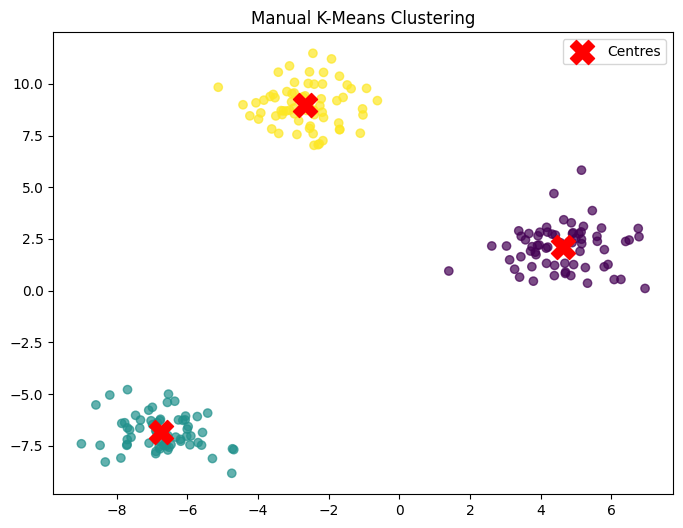

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

def manual_kmeans(X, k=3, max_iter=100, random_state=42):

    rng = np.random.default_rng(random_state)


    centres = X[rng.choice(len(X), k, replace=False)]

    for iteration in range(max_iter):


        dists = np.linalg.norm(
            X[:, np.newaxis] - centres,
            axis=2
        )

        labels = np.argmin(dists, axis=1)


        new_centres = np.array([
            X[labels == k_].mean(axis=0)
            for k_ in range(k)
        ])

        print(
            f"Iter {iteration+1}: centre moved by "
            f"{np.linalg.norm(new_centres - centres):.4f}"
        )

        if np.allclose(centres, new_centres):
            print("→ Converged!")
            break

        centres = new_centres

    return labels, centres



X, _ = make_blobs(
    n_samples=200,
    centers=3,
    random_state=42
)


labels, centres = manual_kmeans(X, k=3)

plt.figure(figsize=(8, 6))
plt.scatter(
    X[:, 0],
    X[:, 1],
    c=labels,
    cmap="viridis",
    alpha=0.7
)

plt.scatter(
    centres[:, 0],
    centres[:, 1],
    c="red",
    s=300,
    marker="X",
    label="Centres"
)

plt.title("Manual K-Means Clustering")
plt.legend()
plt.show()